In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
glucose_df = pd.read_csv('Glucose_measurements.csv')
patient_df = pd.read_csv('Patient_info.csv')

# Exploratory Data Analysis

In [ ]:
# number of rows & column in each csv
print("Glucose_measuremnets.csv shape:", glucose_df.shape)
print("Patient_info.csv shape:", patient_df.shape)

Glucose_measuremnets.csv shape: (22671708, 4)
Patient_info.csv shape: (736, 11)


In [ ]:
# first five rows of each csv
print("Glucose_measurements.csv first 5 rows")
print(glucose_df.head())

print("Patient_info.csv first 5 rows")
print(patient_df.head())

Glucose_measurements.csv first 5 rows
  Patient_ID Measurement_date Measurement_time  Measurement
0  LIB193263       2020-06-09         19:08:00           99
1  LIB193263       2020-06-09         19:23:00           92
2  LIB193263       2020-06-09         19:38:00           86
3  LIB193263       2020-06-09         19:53:00           85
4  LIB193263       2020-06-09         20:08:00           85
Patient_info.csv first 5 rows
  Patient_ID Sex  Birth_year Initial_measurement_date Final_measurement_date  \
0  LIB193263   M        1965               2020-06-09             2022-03-19   
1  LIB193264   F        1975               2020-06-10             2022-03-19   
2  LIB193265   F        1980               2019-01-27             2022-03-19   
3  LIB193266   M        1998               2020-10-08             2022-03-21   
4  LIB193267   F        1980               2020-06-09             2022-03-17   

   Number_of_days_with_measures  Number_of_measurements  \
0                           648 

In [ ]:
print("Glucose_measurements.csv")
glucose_df.info()

print("Patient_info.csv")
patient_df.info()

# Missing values
glucose_df.isna().sum(), patient_df.isna().sum()

Glucose_measurements.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22671708 entries, 0 to 22671707
Data columns (total 4 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   Patient_ID        object
 1   Measurement_date  object
 2   Measurement_time  object
 3   Measurement       int64 
dtypes: int64(1), object(3)
memory usage: 691.9+ MB
Patient_info.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Patient_ID                           736 non-null    object 
 1   Sex                                  736 non-null    object 
 2   Birth_year                           736 non-null    int64  
 3   Initial_measurement_date             736 non-null    object 
 4   Final_measurement_date               736 non-null    object 
 5   Number_of_days_with_measures         736

(Patient_ID          0
 Measurement_date    0
 Measurement_time    0
 Measurement         0
 dtype: int64,
 Patient_ID                               0
 Sex                                      0
 Birth_year                               0
 Initial_measurement_date                 0
 Final_measurement_date                   0
 Number_of_days_with_measures             0
 Number_of_measurements                   0
 Initial_biochemical_parameters_date     13
 Final_biochemical_parameters_date       13
 Number_of_biochemical_parameters        13
 Number_of_diagnostics                  225
 dtype: int64)

In [ ]:
# Compare number of patients in both files
num_glucose_patients = glucose_df["Patient_ID"].nunique()
num_patient_info = patient_df["Patient_ID"].nunique()

num_glucose_patients, num_patient_info

(736, 736)

In [ ]:
# Statistics of Glucose_measurments.csv by grouping patients
measurements_per_patient = glucose_df.groupby("Patient_ID").size()

measurements_per_patient.describe()

,0
count,736.000000
mean,30803.951087
std,25704.868842
min,401.000000
25%,10674.000000
50%,25003.500000
75%,45687.500000
max,137293.000000


<Axes: >

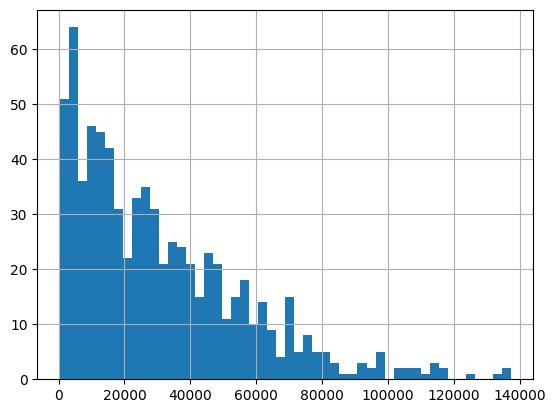

In [ ]:
# Distribution Inspection
measurements_per_patient.hist(bins=50)

In [ ]:
# 1. Exact row duplicates
duplicate_rows = glucose_df.duplicated().sum()
print("Exact duplicate rows:", duplicate_rows)

# 2. Logical duplicates (same patient, same date, same time)
logical_duplicates = glucose_df.duplicated(
    subset=["Patient_ID", "Measurement_date", "Measurement_time"]
).sum()
print("Logical duplicates (Patient + Date + Time):", logical_duplicates)

# View examples
glucose_df[
    glucose_df.duplicated(
        subset=["Patient_ID", "Measurement_date", "Measurement_time"],
        keep=False
    )
].sort_values(["Patient_ID", "Measurement_date", "Measurement_time"]).head(10)

# 3. Check duplicate patient IDs in patient_info
patient_info_duplicates = patient_df["Patient_ID"].duplicated().sum()
print("Duplicate Patient_IDs in patient_info:", patient_info_duplicates)


Exact duplicate rows: 0
Logical duplicates (Patient + Date + Time): 22029
Duplicate Patient_IDs in patient_info: 0


In [ ]:
# Combine date and time
glucose_df["Measurement_Datetime"] = pd.to_datetime(
    glucose_df["Measurement_date"] + " " + glucose_df["Measurement_time"],
    errors="coerce"
)

# Check result -> 5 columns
glucose_df

,Patient_ID,Measurement_date,Measurement_time,Measurement,Measurement_Datetime
0,LIB193263,2020-06-09,19:08:00,99,2020-06-09 19:08:00
1,LIB193263,2020-06-09,19:23:00,92,2020-06-09 19:23:00
2,LIB193263,2020-06-09,19:38:00,86,2020-06-09 19:38:00
3,LIB193263,2020-06-09,19:53:00,85,2020-06-09 19:53:00
4,LIB193263,2020-06-09,20:08:00,85,2020-06-09 20:08:00
...,...,...,...,...,...
22671703,LIB194166,2022-03-17,15:08:00,169,2022-03-17 15:08:00
22671704,LIB194166,2022-03-17,15:23:00,206,2022-03-17 15:23:00
22671705,LIB194166,2022-03-17,15:38:00,215,2022-03-17 15:38:00
22671706,LIB194166,2022-03-17,15:53:00,204,2022-03-17 15:53:00


In [ ]:
# Check Missing Timestamps
glucose_df["Measurement_Datetime"].isna().sum()

np.int64(0)

In [ ]:
# Sort properly
glucose_df = glucose_df.sort_values(["Patient_ID", "Measurement_Datetime"])

# Compute time difference per patient
glucose_df["time_diff_min"] = (
    glucose_df.groupby("Patient_ID")["Measurement_Datetime"]
    .diff()
    .dt.total_seconds() / 60
)

glucose_df["time_diff_min"].describe()

,time_diff_min
count,2.267097e+07
mean,2.073637e+01
std,1.206392e+03
min,0.000000e+00
25%,1.500000e+01
50%,1.500000e+01
75%,1.500000e+01
max,1.516981e+06


In [ ]:
# Check Intervals -> 15 min interval
glucose_df["time_diff_min"].quantile([0.5, 0.9, 0.95, 0.99])

,time_diff_min
0.50,15.0
0.90,15.0
0.95,16.0
0.99,17.0


In [ ]:
glucose_df["Measurement"].describe()

,Measurement
count,2.267171e+07
mean,1.647837e+02
std,7.157474e+01
min,4.000000e+01
25%,1.120000e+02
50%,1.530000e+02
75%,2.060000e+02
max,5.000000e+02


<Axes: >

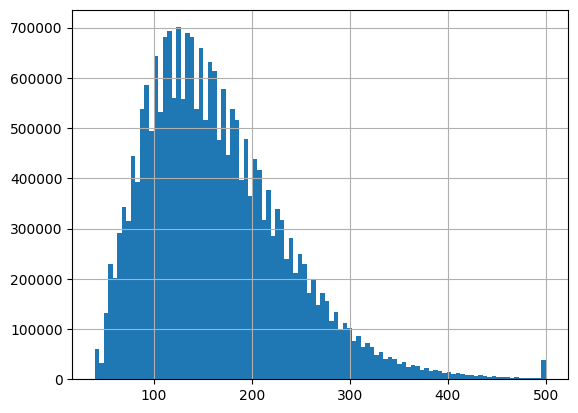

In [ ]:
glucose_df["Measurement"].hist(bins=100)

In [ ]:
# Age calculation
patient_df["Age"] = 2022 - patient_df["Birth_year"]

patient_df["Age"].describe()

,Age
count,736.000000
mean,45.336957
std,15.772724
min,17.000000
25%,32.000000
50%,45.000000
75%,57.000000
max,86.000000


In [ ]:
patient_df["Sex"].value_counts()

,count
Sex,
F,373
M,363


In [ ]:
# Global earliest and latest glucose timestamps
glucose_df["Measurement_Datetime"].min(), glucose_df["Measurement_Datetime"].max()

(Timestamp('2018-01-06 13:39:00'), Timestamp('2022-03-21 21:00:00'))

In [ ]:
# Check for negative time differences
negative_time_jumps = glucose_df[glucose_df["time_diff_min"] < 0]

negative_time_jumps.shape

(0, 6)

In [ ]:
negative_time_jumps.head()

,Patient_ID,Measurement_date,Measurement_time,Measurement,Measurement_Datetime,time_diff_min


In [ ]:
zero_gap = glucose_df[glucose_df["time_diff_min"] == 0]

zero_gap.shape

(22029, 6)

In [ ]:
patient_duration_days = (
    glucose_df.groupby("Patient_ID")["Measurement_Datetime"]
    .agg(lambda x: (x.max() - x.min()).days)
)

patient_duration_days.describe()

,Measurement_Datetime
count,736.000000
mean,443.040761
std,367.402441
min,6.000000
25%,151.500000
50%,334.000000
75%,646.250000
max,1531.000000


<Axes: >

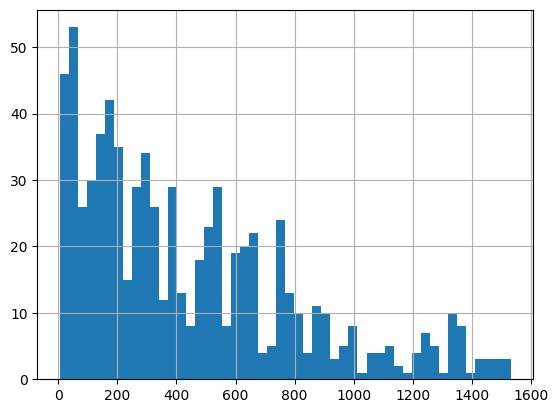

In [ ]:
patient_duration_days.hist(bins=50)

In [ ]:
# 1. Set datetime as index for time series analysis
glucose_df = glucose_df.set_index('Measurement_Datetime')

In [ ]:
# 2. Check outlier distribution within 40-500 range
# Extreme values near boundaries
boundary_check = pd.DataFrame({
    'near_low_40': (glucose_df['Measurement'] <= 50).sum(),
    'near_high_500': (glucose_df['Measurement'] >= 450).sum(),
    'hypo_70': (glucose_df['Measurement'] < 70).sum(),
    'hyper_180': (glucose_df['Measurement'] > 180).sum(),
    'hyper_250': (glucose_df['Measurement'] > 250).sum()
}, index=['count'])

In [ ]:
print("Clinically significant thresholds:")
print(boundary_check.T)

Clinically significant thresholds:
                 count
near_low_40     101262
near_high_500    74045
hypo_70        1076420
hyper_180      8088289
hyper_250      2695929


In [ ]:
# 3. Time of day analysis
glucose_df['hour'] = glucose_df.index.hour
hourly_stats = glucose_df.groupby('hour')['Measurement'].agg(['mean', 'std', 'count'])

In [ ]:
print("\nGlucose by hour of day:")
print(hourly_stats.head())


Glucose by hour of day:
            mean        std   count
hour                               
0     167.722885  74.366737  813761
1     167.012195  72.255743  848382
2     166.387016  71.277011  901315
3     164.813475  70.697693  939519
4     162.054748  69.972920  962263


In [ ]:
# 4. Autocorrelation check (for first patient as example)
sample_patient = glucose_df[glucose_df['Patient_ID'] == glucose_df['Patient_ID'].iloc[0]]

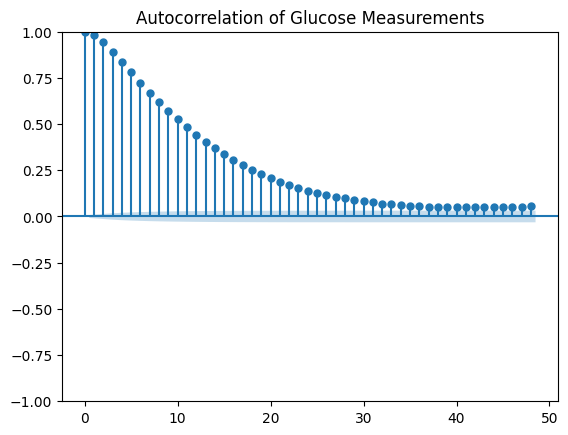

In [ ]:
# Plot autocorrelation for lags up to 48 (12 hours)
plot_acf(sample_patient['Measurement'], lags=48)
plt.title('Autocorrelation of Glucose Measurements')
plt.show()

In [ ]:
# 5. Rate of change analysis
glucose_df['glucose_rate'] = glucose_df.groupby('Patient_ID')['Measurement'].diff() / glucose_df['time_diff_min']

# Fix infinite values and long gaps
glucose_df['glucose_rate'] = glucose_df['glucose_rate'].replace([np.inf, -np.inf], np.nan)
glucose_df.loc[glucose_df['time_diff_min'] > 120, 'glucose_rate'] = np.nan

clean_rate_stats = glucose_df['glucose_rate'].describe()
print("Clean glucose rate statistics:")
print(clean_rate_stats)

Clean glucose rate statistics:
count    2.256870e+07
mean     3.909673e-03
std      2.959142e+00
min     -4.070000e+02
25%     -4.666667e-01
50%     -6.666667e-02
75%      4.000000e-01
max      4.040000e+02
Name: glucose_rate, dtype: float64


In [ ]:
# Check dangerous rates (fast drops > 2 mg/dL per minute)
fast_drops_clean = (glucose_df['glucose_rate'] < -2).sum()
fast_rises_clean = (glucose_df['glucose_rate'] > 2).sum()

print(f"\nClean fast drops (>2 mg/dL/min): {fast_drops_clean}")
print(f"Clean fast rises (>2 mg/dL/min): {fast_rises_clean}")


Clean fast drops (>2 mg/dL/min): 537532
Clean fast rises (>2 mg/dL/min): 740310


In [ ]:
# 6. Missing pattern analysis (gaps > 30 minutes)
long_gaps = glucose_df[glucose_df['time_diff_min'] > 30]
gap_by_hour = long_gaps.groupby(long_gaps.index.hour).size()

print("\nLong gaps (>30 min) by hour of day:")
print(gap_by_hour.head())


Long gaps (>30 min) by hour of day:
Measurement_Datetime
0    21767
1    22318
2    17310
3    10261
4     5754
dtype: int64


In [ ]:
# 7. Weekly patterns
glucose_df['weekday'] = glucose_df.index.weekday
weekday_stats = glucose_df.groupby('weekday')['Measurement'].agg(['mean', 'std'])

print("\nGlucose by day of week (0=Monday):")
print(weekday_stats)


Glucose by day of week (0=Monday):
               mean        std
weekday                       
0        166.927109  71.392442
1        164.061688  70.460606
2        162.818677  70.436998
3        162.896099  70.681730
4        163.203368  71.418728
5        165.499504  72.950466
6        168.171696  73.477504


In [ ]:
# 8. Reset index for further processing
glucose_df = glucose_df.reset_index()

# Data Cleaning

In [ ]:
# Calculate patient metrics for filtering
patient_metrics = []

for patient_id in glucose_df['Patient_ID'].unique():
    patient_data = glucose_df[glucose_df['Patient_ID'] == patient_id].copy()

    # Sort by time
    patient_data = patient_data.sort_values('Measurement_Datetime')

    # Basic metrics
    total_days = (patient_data['Measurement_Datetime'].max() - patient_data['Measurement_Datetime'].min()).days
    total_measurements = len(patient_data)

    # Gap analysis
    regular_intervals = ((patient_data['time_diff_min'] >= 13) & (patient_data['time_diff_min'] <= 17)).sum()
    gap_percentage = (patient_data['time_diff_min'] > 30).sum() / total_measurements * 100

    # Clinical events
    hypo_count = (patient_data['Measurement'] < 70).sum()
    hyper_count = (patient_data['Measurement'] > 180).sum()

    patient_metrics.append({
        'Patient_ID': patient_id,
        'total_days': total_days,
        'total_measurements': total_measurements,
        'regular_intervals': regular_intervals,
        'regularity_percentage': (regular_intervals / total_measurements) * 100,
        'gap_percentage': gap_percentage,
        'hypo_count': hypo_count,
        'hyper_count': hyper_count,
        'has_both_events': (hypo_count > 0) and (hyper_count > 0)
    })

# Create metrics dataframe
metrics_df = pd.DataFrame(patient_metrics)

# Display metrics summary
print("Patient metrics summary:")
print(metrics_df[['total_days', 'total_measurements', 'regularity_percentage', 'gap_percentage']].describe())


Patient metrics summary:
        total_days  total_measurements  regularity_percentage  gap_percentage
count   736.000000          736.000000             736.000000      736.000000
mean    443.040761        30803.951087              97.614461        0.665983
std     367.402441        25704.868842               6.078650        0.461917
min       6.000000          401.000000              21.031197        0.000000
25%     151.500000        10674.000000              98.459451        0.311161
50%     334.000000        25003.500000              98.973926        0.571001
75%     646.250000        45687.500000              99.320592        0.885816
max    1531.000000       137293.000000              99.912968        2.743142


In [ ]:
# Set filtering thresholds
MIN_DAYS = 180
MIN_MEASUREMENTS = 2880  # 30 days at 15-min intervals
MIN_REGULARITY = 85  # % of intervals that are 15±2 minutes
MAX_GAP_PERCENTAGE = 20  # % of intervals >30 minutes
REQUIRE_BOTH_EVENTS = False  # Set to True if needed

# Apply filters
filtered_patients = metrics_df[
    (metrics_df['total_days'] >= MIN_DAYS) &
    (metrics_df['total_measurements'] >= MIN_MEASUREMENTS) &
    (metrics_df['regularity_percentage'] >= MIN_REGULARITY) &
    (metrics_df['gap_percentage'] <= MAX_GAP_PERCENTAGE)
]

if REQUIRE_BOTH_EVENTS:
    filtered_patients = filtered_patients[filtered_patients['has_both_events']]


In [ ]:
# Report filtering results
print(f"\nOriginal patients: {len(metrics_df)}")
print(f"Filtered patients: {len(filtered_patients)}")
print(f"Patients removed: {len(metrics_df) - len(filtered_patients)}")

print("\nPatients removed by each criterion:")
print(f"  - Days < {MIN_DAYS}: {(metrics_df['total_days'] < MIN_DAYS).sum()}")
print(f"  - Measurements < {MIN_MEASUREMENTS}: {(metrics_df['total_measurements'] < MIN_MEASUREMENTS).sum()}")
print(f"  - Regularity < {MIN_REGULARITY}%: {(metrics_df['regularity_percentage'] < MIN_REGULARITY).sum()}")
print(f"  - Gaps > {MAX_GAP_PERCENTAGE}%: {(metrics_df['gap_percentage'] > MAX_GAP_PERCENTAGE).sum()}")
if REQUIRE_BOTH_EVENTS:
    print(f"  - Missing both hypo/hyper events: {(~metrics_df['has_both_events']).sum()}")


Original patients: 736
Filtered patients: 489
Patients removed: 247

Patients removed by each criterion:
  - Days < 180: 223
  - Measurements < 2880: 45
  - Regularity < 85%: 27
  - Gaps > 20%: 0


In [ ]:
# Create filtered glucose dataset
filtered_glucose_df = glucose_df[glucose_df['Patient_ID'].isin(filtered_patients['Patient_ID'])]

print(f"\nOriginal measurements: {len(glucose_df):,}")
print(f"Filtered measurements: {len(filtered_glucose_df):,}")
print(f"Measurements removed: {len(glucose_df) - len(filtered_glucose_df):,}")
print(f"Data reduction: {(1 - len(filtered_glucose_df)/len(glucose_df))*100:.1f}%")


Original measurements: 22,671,708
Filtered measurements: 19,374,923
Measurements removed: 3,296,785
Data reduction: 14.5%


In [ ]:
# Merge demographics for filtered patients
filtered_demographics = patient_df[['Patient_ID', 'Sex', 'Birth_year']].copy()
filtered_demographics['Age'] = 2022 - filtered_demographics['Birth_year']

# Merge with filtered glucose data
merged_df = filtered_glucose_df.merge(
    filtered_demographics[['Patient_ID', 'Sex', 'Age']],
    on='Patient_ID',
    how='left'
)

print(f"Merged dataset shape: {merged_df.shape}")
print(f"Columns: {merged_df.columns.tolist()}")

Merged dataset shape: (19374923, 11)
Columns: ['Measurement_Datetime', 'Patient_ID', 'Measurement_date', 'Measurement_time', 'Measurement', 'time_diff_min', 'hour', 'glucose_rate', 'weekday', 'Sex', 'Age']


In [ ]:
merged_df.head()

,Measurement_Datetime,Patient_ID,Measurement_date,Measurement_time,Measurement,time_diff_min,hour,glucose_rate,weekday,Sex,Age
0,2020-06-09 19:08:00,LIB193263,2020-06-09,19:08:00,99,NaN,19,NaN,1,M,57
1,2020-06-09 19:23:00,LIB193263,2020-06-09,19:23:00,92,15.0,19,-0.466667,1,M,57
2,2020-06-09 19:38:00,LIB193263,2020-06-09,19:38:00,86,15.0,19,-0.400000,1,M,57
3,2020-06-09 19:53:00,LIB193263,2020-06-09,19:53:00,85,15.0,19,-0.066667,1,M,57
4,2020-06-09 20:08:00,LIB193263,2020-06-09,20:08:00,85,15.0,20,0.000000,1,M,57


In [ ]:
# Keep only essential columns in merged_df
essential_cols = ['Measurement_Datetime', 'Patient_ID', 'Measurement',
                  'time_diff_min', 'Sex', 'Age']
merged_df = merged_df[essential_cols].copy()

print(f"Simplified dataframe shape: {merged_df.shape}")
print(f"Columns: {merged_df.columns.tolist()}")

Simplified dataframe shape: (19374923, 6)
Columns: ['Measurement_Datetime', 'Patient_ID', 'Measurement', 'time_diff_min', 'Sex', 'Age']


In [ ]:
merged_df.head()

,Measurement_Datetime,Patient_ID,Measurement,time_diff_min,Sex,Age
0,2020-06-09 19:08:00,LIB193263,99,NaN,M,57
1,2020-06-09 19:23:00,LIB193263,92,15.0,M,57
2,2020-06-09 19:38:00,LIB193263,86,15.0,M,57
3,2020-06-09 19:53:00,LIB193263,85,15.0,M,57
4,2020-06-09 20:08:00,LIB193263,85,15.0,M,57


In [ ]:
# 1. Check current state
print(f"Initial shape: {merged_df.shape}")
print(f"Initial columns: {merged_df.columns.tolist()}")

# 2. Check for missing values
print("\nMissing values check:")
print(merged_df.isna().sum())

# 3. Check for duplicate timestamps per patient
duplicate_timestamps = merged_df.duplicated(subset=['Patient_ID', 'Measurement_Datetime']).sum()
print(f"\nDuplicate timestamps (same patient + same time): {duplicate_timestamps}")

# 4. Check clinical bounds
in_range = merged_df['Measurement'].between(40, 500)
print(f"\nMeasurements within 40-500 mg/dL: {in_range.sum()}/{len(merged_df)}")
print(f"Outside range: {(~in_range).sum()}")

# 5. Check temporal ordering
merged_df = merged_df.sort_values(['Patient_ID', 'Measurement_Datetime']).reset_index(drop=True)


Initial shape: (19374923, 6)
Initial columns: ['Measurement_Datetime', 'Patient_ID', 'Measurement', 'time_diff_min', 'Sex', 'Age']

Missing values check:
Measurement_Datetime      0
Patient_ID                0
Measurement               0
time_diff_min           489
Sex                       0
Age                       0
dtype: int64

Duplicate timestamps (same patient + same time): 7629

Measurements within 40-500 mg/dL: 19374923/19374923
Outside range: 0


In [ ]:
# Remove time_diff_min column
merged_df = merged_df.drop(columns=['time_diff_min'])

print(f"Shape after removal: {merged_df.shape}")
print(f"Columns: {merged_df.columns.tolist()}")

Shape after removal: (19374923, 5)
Columns: ['Measurement_Datetime', 'Patient_ID', 'Measurement', 'Sex', 'Age']


In [ ]:
# Count duplicates before removal
duplicates_before = merged_df.duplicated(subset=['Patient_ID', 'Measurement_Datetime']).sum()
print(f"Duplicate timestamps before: {duplicates_before}")

Duplicate timestamps before: 7629


In [ ]:

# Remove duplicates, keep first occurrence
merged_df = merged_df.drop_duplicates(subset=['Patient_ID', 'Measurement_Datetime'], keep='first')

# Re-sort
merged_df = merged_df.sort_values(['Patient_ID', 'Measurement_Datetime']).reset_index(drop=True)


In [ ]:
# Count after
duplicates_after = merged_df.duplicated(subset=['Patient_ID', 'Measurement_Datetime']).sum()
print(f"Duplicate timestamps after: {duplicates_after}")

print(f"\nRows removed: {duplicates_before}")
print(f"New shape: {merged_df.shape}")

Duplicate timestamps after: 0

Rows removed: 7629
New shape: (19367294, 5)


In [ ]:
merged_df.head()

,Measurement_Datetime,Patient_ID,Measurement,Sex,Age
0,2020-06-09 19:08:00,LIB193263,99,M,57
1,2020-06-09 19:23:00,LIB193263,92,M,57
2,2020-06-09 19:38:00,LIB193263,86,M,57
3,2020-06-09 19:53:00,LIB193263,85,M,57
4,2020-06-09 20:08:00,LIB193263,85,M,57


In [ ]:
# 1. Verify demographics
print("Missing Age:", merged_df['Age'].isna().sum())
print("Missing Sex:", merged_df['Sex'].isna().sum())

# 2. Verify data types
print("\nData types:")
print(merged_df.dtypes)

# 3. Check patient count still 489
print(f"\nUnique patients: {merged_df['Patient_ID'].nunique()}")

# 4. Final shape
print(f"Final dataset shape: {merged_df.shape}")

Missing Age: 0
Missing Sex: 0

Data types:
Measurement_Datetime    datetime64[ns]
Patient_ID                      object
Measurement                      int64
Sex                             object
Age                              int64
dtype: object

Unique patients: 489
Final dataset shape: (19367294, 5)


19,367,294 measurements (from 19,374,923 → removed 7,629 duplicates)

489 patients (as filtered)

5 columns: Measurement_Datetime, Patient_ID, Measurement, Sex, Age

No missing values

Correct data types

All values clinically valid (no outliers)

In [ ]:
# Save merged_df to file
merged_df.to_parquet('merged_filtered_data.parquet', index=False)  # parquet is efficient
print("Saved merged_df to merged_filtered_data.parquet")

# Remove large original files from memory
del glucose_df
del patient_df
import gc
gc.collect()
print("Freed memory from original dataframes")


Saved merged_df to merged_filtered_data.parquet
Freed memory from original dataframes
Loaded merged_df: (19367294, 5)


# Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
# Load back if needed (smaller memory footprint)
merged_df = pd.read_parquet('merged_filtered_data.parquet')
print(f"Loaded merged_df: {merged_df.shape}")

Loaded merged_df: (19367294, 5)


In [3]:
# Add time_diff_min for segmenting
merged_df['time_diff_min'] = merged_df.groupby('Patient_ID')['Measurement_Datetime'].diff().dt.total_seconds() / 60
merged_df['time_diff_min'] = merged_df['time_diff_min'].fillna(0)

print("1. Time difference calculation:")
print(f"   Missing values: {merged_df['time_diff_min'].isna().sum()}")
print(f"   Min time gap: {merged_df['time_diff_min'].min():.1f} min")
print(f"   Max time gap: {merged_df['time_diff_min'].max():.1f} min")
print(f"   Mean time gap: {merged_df['time_diff_min'].mean():.1f} min")

1. Time difference calculation:
   Missing values: 0
   Min time gap: 0.0 min
   Max time gap: 1516981.0 min
   Mean time gap: 21.1 min


In [4]:
# Extract time components
merged_df['hour'] = merged_df['Measurement_Datetime'].dt.hour
merged_df['weekday'] = merged_df['Measurement_Datetime'].dt.weekday  # 0=Monday
merged_df['month'] = merged_df['Measurement_Datetime'].dt.month

print(f"   Added: hour, weekday, month")
print(f"   Hour range: {merged_df['hour'].min()} to {merged_df['hour'].max()}")
print(f"   Weekday range: {merged_df['weekday'].min()} to {merged_df['weekday'].max()}")
print(f"   Month range: {merged_df['month'].min()} to {merged_df['month'].max()}")


   Added: hour, weekday, month
   Hour range: 0 to 23
   Weekday range: 0 to 6
   Month range: 1 to 12


In [5]:
# Calculate glucose rate of change
print("\n3. Calculating glucose rate of change...")
merged_df['glucose_rate'] = merged_df.groupby('Patient_ID')['Measurement'].diff() / merged_df['time_diff_min']


3. Calculating glucose rate of change...


In [6]:
# Clean rate values
merged_df['glucose_rate'] = merged_df['glucose_rate'].replace([np.inf, -np.inf], np.nan)
merged_df.loc[merged_df['time_diff_min'] > 120, 'glucose_rate'] = np.nan
merged_df['glucose_rate'] = merged_df['glucose_rate'].fillna(0)

print(f"   Glucose rate - Min: {merged_df['glucose_rate'].min():.2f} mg/dL/min")
print(f"   Glucose rate - Max: {merged_df['glucose_rate'].max():.2f} mg/dL/min")
print(f"   Glucose rate - Mean: {merged_df['glucose_rate'].mean():.3f} mg/dL/min")

   Glucose rate - Min: -282.00 mg/dL/min
   Glucose rate - Max: 289.00 mg/dL/min
   Glucose rate - Mean: -0.001 mg/dL/min


In [7]:
# Add clinical flags
print("\n4. Adding clinical flags...")
merged_df['is_hypo'] = (merged_df['Measurement'] < 70).astype(int)
merged_df['is_hyper'] = (merged_df['Measurement'] > 180).astype(int)
merged_df['is_extreme_hyper'] = (merged_df['Measurement'] > 250).astype(int)

print(f"   Hypo events (<70): {merged_df['is_hypo'].sum():,}")
print(f"   Hyper events (>180): {merged_df['is_hyper'].sum():,}")
print(f"   Extreme hyper (>250): {merged_df['is_extreme_hyper'].sum():,}")


4. Adding clinical flags...
   Hypo events (<70): 949,129
   Hyper events (>180): 6,828,902
   Extreme hyper (>250): 2,229,268


In [8]:
# Encode Sex (M=1, F=0)
print("\n5. Encoding categorical features...")
merged_df['Sex_encoded'] = merged_df['Sex'].map({'M': 1, 'F': 0}).astype(int)
print(f"   Male (1): {(merged_df['Sex_encoded'] == 1).sum():,}")
print(f"   Female (0): {(merged_df['Sex_encoded'] == 0).sum():,}")

print(f"\n✓ Feature engineering complete")
print(f"   Final columns: {merged_df.columns.tolist()}")
print(f"   Final shape: {merged_df.shape}")


5. Encoding categorical features...
   Male (1): 8,902,519
   Female (0): 10,464,775

✓ Feature engineering complete
   Final columns: ['Measurement_Datetime', 'Patient_ID', 'Measurement', 'Sex', 'Age', 'time_diff_min', 'hour', 'weekday', 'month', 'glucose_rate', 'is_hypo', 'is_hyper', 'is_extreme_hyper', 'Sex_encoded']
   Final shape: (19367294, 14)


In [9]:
# Cyclical encoding for time features
merged_df['hour_sin'] = np.sin(2 * np.pi * merged_df['hour'] / 24)
merged_df['hour_cos'] = np.cos(2 * np.pi * merged_df['hour'] / 24)
merged_df['weekday_sin'] = np.sin(2 * np.pi * merged_df['weekday'] / 7)
merged_df['weekday_cos'] = np.cos(2 * np.pi * merged_df['weekday'] / 7)
merged_df['month_sin'] = np.sin(2 * np.pi * merged_df['month'] / 12)
merged_df['month_cos'] = np.cos(2 * np.pi * merged_df['month'] / 12)


In [10]:
merged_df.head()

,Measurement_Datetime,Patient_ID,Measurement,Sex,Age,time_diff_min,hour,weekday,month,glucose_rate,is_hypo,is_hyper,is_extreme_hyper,Sex_encoded,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
0,2020-06-09 19:08:00,LIB193263,99,M,57,0.0,19,1,6,0.000000,0,0,0,1,-0.965926,0.258819,0.781831,0.62349,1.224647e-16,-1.0
1,2020-06-09 19:23:00,LIB193263,92,M,57,15.0,19,1,6,-0.466667,0,0,0,1,-0.965926,0.258819,0.781831,0.62349,1.224647e-16,-1.0
2,2020-06-09 19:38:00,LIB193263,86,M,57,15.0,19,1,6,-0.400000,0,0,0,1,-0.965926,0.258819,0.781831,0.62349,1.224647e-16,-1.0
3,2020-06-09 19:53:00,LIB193263,85,M,57,15.0,19,1,6,-0.066667,0,0,0,1,-0.965926,0.258819,0.781831,0.62349,1.224647e-16,-1.0
4,2020-06-09 20:08:00,LIB193263,85,M,57,15.0,20,1,6,0.000000,0,0,0,1,-0.866025,0.500000,0.781831,0.62349,1.224647e-16,-1.0


In [11]:
merged_df.to_parquet('feature_engineered_data.parquet', index=False)

# Data Transformation

In [12]:
# Reduction due to memory
# 1. Keep only last 90 days per patient
merged_df['days_from_end'] = merged_df.groupby('Patient_ID')['Measurement_Datetime'].transform(
    lambda x: (x.max() - x).dt.days
)

reduced_df = merged_df[merged_df['days_from_end'] <= 90].copy()
print(f"1. Last 90 days only: {len(merged_df):,} → {len(reduced_df):,} rows")

# 2. Downsample to 30-minute intervals (keep every other measurement)
reduced_df['row_num'] = reduced_df.groupby('Patient_ID').cumcount()
reduced_df = reduced_df[reduced_df['row_num'] % 2 == 0].copy()  # Keep every other row
del reduced_df['row_num']

print(f"2. 30-minute intervals: {len(reduced_df):,} rows remaining")
print(f"   Total reduction: {(1 - len(reduced_df)/len(merged_df))*100:.1f}%")

1. Last 90 days only: 19,367,294 → 3,585,899 rows
2. 30-minute intervals: 1,793,065 rows remaining
   Total reduction: 90.7%


In [13]:
print(reduced_df['time_diff_min'].describe())
print(reduced_df['time_diff_min'].quantile([0.5, 0.9, 0.99]))

count    1.793065e+06
mean     2.391876e+01
std      1.445864e+03
min      1.000000e+00
25%      1.500000e+01
50%      1.500000e+01
75%      1.500000e+01
max      8.166130e+05
Name: time_diff_min, dtype: float64
0.50    15.0
0.90    15.0
0.99    17.0
Name: time_diff_min, dtype: float64


In [14]:
# Define gap threshold for segments
GAP_THRESHOLD_MIN = 30

# Create segments within each patient (break at gaps >30 minutes)
reduced_df['new_segment'] = reduced_df['time_diff_min'] > GAP_THRESHOLD_MIN
reduced_df['segment_id'] = reduced_df.groupby('Patient_ID')['new_segment'].cumsum()

print(f"   Gap threshold: {GAP_THRESHOLD_MIN} minutes")
print(f"   Total segments created: {reduced_df['segment_id'].nunique()}")
print(f"   Gaps > threshold: {reduced_df['new_segment'].sum()}")


   Gap threshold: 30 minutes
   Total segments created: 89
   Gaps > threshold: 12019


In [15]:
# Calculate segment lengths
reduced_df['segment_length'] = reduced_df.groupby(['Patient_ID', 'segment_id'])['segment_id'].transform('size')

print(f"\n2. Segment length analysis:")
print(f"   Min segment length: {reduced_df['segment_length'].min()}")
print(f"   Max segment length: {reduced_df['segment_length'].max()}")
print(f"   Mean segment length: {reduced_df['segment_length'].mean():.1f}")



2. Segment length analysis:
   Min segment length: 1
   Max segment length: 2651
   Mean segment length: 441.1


In [16]:
MIN_SEGMENT_LENGTH = 28  # 24 (window) + 4 (prediction)

# Get all patient IDs
all_patient_ids = reduced_df['Patient_ID'].unique()
print(f"   Total patients to process: {len(all_patient_ids)}")

# Process in smaller batches
BATCH_SIZE = 50
filtered_chunks = []
total_patients_processed = 0

for i in range(0, len(all_patient_ids), BATCH_SIZE):
    batch_ids = all_patient_ids[i:i+BATCH_SIZE]
    batch_df = reduced_df[reduced_df['Patient_ID'].isin(batch_ids)].copy()

    # Calculate segment length for this batch only
    batch_df['segment_length'] = batch_df.groupby(['Patient_ID', 'segment_id'])['segment_id'].transform('size')

    # Filter within batch
    batch_filtered = batch_df[batch_df['segment_length'] >= MIN_SEGMENT_LENGTH]
    filtered_chunks.append(batch_filtered)

    total_patients_processed += len(batch_ids)
    print(f"   Processed patients {total_patients_processed-len(batch_ids)+1}-{total_patients_processed} of {len(all_patient_ids)}")


   Total patients to process: 489
   Processed patients 1-50 of 489
   Processed patients 51-100 of 489
   Processed patients 101-150 of 489
   Processed patients 151-200 of 489
   Processed patients 201-250 of 489
   Processed patients 251-300 of 489
   Processed patients 301-350 of 489
   Processed patients 351-400 of 489
   Processed patients 401-450 of 489
   Processed patients 451-489 of 489


In [17]:
# Combine filtered chunks into reduced_df
reduced_df = pd.concat(filtered_chunks, ignore_index=True)

print(f"\n4. Filtering results:")
print(f"   Rows after filtering: {len(reduced_df):,}")
print(f"   Patients remaining: {reduced_df['Patient_ID'].nunique()}")
print(f"   Segments remaining: {reduced_df['segment_id'].nunique()}")
print(f"   Average segment length: {reduced_df['segment_length'].mean():.1f}")

print("\n✓ Segment filtering complete")


4. Filtering results:
   Rows after filtering: 1,772,834
   Patients remaining: 489
   Segments remaining: 80
   Average segment length: 445.9

✓ Segment filtering complete


In [18]:
print(reduced_df['time_diff_min'].describe())
print(reduced_df['time_diff_min'].quantile([0.5, 0.9, 0.99]))

count    1.772834e+06
mean     2.286629e+01
std      1.400407e+03
min      1.000000e+00
25%      1.500000e+01
50%      1.500000e+01
75%      1.500000e+01
max      8.166130e+05
Name: time_diff_min, dtype: float64
0.50    15.0
0.90    15.0
0.99    17.0
Name: time_diff_min, dtype: float64


In [19]:
print("Segments with length < 32:",
      (reduced_df['segment_length'] < 32).sum())


Segments with length < 32: 23005


Summary(old before reduction):

19.3M rows remaining (from 19.367M) → removed only 67,292 short segments

489 patients all kept

1,231 segments remaining (from 1,233) → removed only 2 very short segments

Average segment length: 447 measurements (≈4.7 days continuous data)

# Data Splitting

In [20]:
from sklearn.model_selection import train_test_split

unique_patients = reduced_df['Patient_ID'].unique()

train_patients, temp_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5,
    random_state=42
)

In [21]:
train_df = reduced_df[reduced_df['Patient_ID'].isin(train_patients)]
val_df   = reduced_df[reduced_df['Patient_ID'].isin(val_patients)]
test_df  = reduced_df[reduced_df['Patient_ID'].isin(test_patients)]

# Windowing

In [22]:
# Define windowing parameters
WINDOW_SIZE = 24
PRED_HORIZON = 4
STRIDE = 4
BATCH_SIZE = 25

def create_windows(segment_df, window_size, horizon, stride, patient_id):
    dynamic_features = [
        'Measurement',
        'hour_sin', 'hour_cos',
        'weekday_sin', 'weekday_cos',
        'month_sin', 'month_cos',
        'glucose_rate',
        'is_hypo', 'is_hyper'
    ]

    static_features = ['Age', 'Sex_encoded']

    dynamic_vals = segment_df[dynamic_features].values
    static_vals = segment_df[static_features].iloc[0].values

    X_dyn, X_stat, y, pids = [], [], [], []

    max_start = len(dynamic_vals) - window_size - horizon + 1
    if max_start <= 0:
        return None, None, None, None

    for start in range(0, max_start, stride):
        end = start + window_size
        X_dyn.append(dynamic_vals[start:end])
        X_stat.append(static_vals)
        y.append(segment_df['Measurement'].values[end:end+horizon])
        pids.append(patient_id)

    return (
        np.array(X_dyn),
        np.array(X_stat),
        np.array(y),
        np.array(pids)
    )

In [23]:
file_counter = 0
patient_ids = train_df['Patient_ID'].unique()

for batch_start in range(0, len(patient_ids), BATCH_SIZE):
    batch_ids = patient_ids[batch_start:batch_start + BATCH_SIZE]
    batch_df = train_df[train_df['Patient_ID'].isin(batch_ids)]

    BX_dyn, BX_stat, By, BP = [], [], [], []

    for pid in batch_ids:
        patient_df = batch_df[batch_df['Patient_ID'] == pid]

        px_dyn, px_stat, py, pp = [], [], [], []

        for _, seg_df in patient_df.groupby('segment_id'):
            seg_df = seg_df.sort_values('Measurement_Datetime')

            Xd, Xs, y, p = create_windows(
                seg_df, WINDOW_SIZE, PRED_HORIZON, STRIDE, pid
            )

            if Xd is not None:
                px_dyn.append(Xd)
                px_stat.append(Xs)
                py.append(y)
                pp.append(p)

        if px_dyn:
            BX_dyn.append(np.concatenate(px_dyn))
            BX_stat.append(np.concatenate(px_stat))
            By.append(np.concatenate(py))
            BP.append(np.concatenate(pp))

    if BX_dyn:
        np.save(f'X_dyn_train_{file_counter}.npy', np.concatenate(BX_dyn))
        np.save(f'X_stat_train_{file_counter}.npy', np.concatenate(BX_stat))
        np.save(f'y_train_{file_counter}.npy', np.concatenate(By))
        np.save(f'pids_train_{file_counter}.npy', np.concatenate(BP))
        print(f"✓ TRAIN batch {file_counter} saved")
        file_counter += 1

    del batch_df, BX_dyn, BX_stat, By, BP
    import gc; gc.collect()


✓ TRAIN batch 0 saved
✓ TRAIN batch 1 saved
✓ TRAIN batch 2 saved
✓ TRAIN batch 3 saved
✓ TRAIN batch 4 saved
✓ TRAIN batch 5 saved
✓ TRAIN batch 6 saved
✓ TRAIN batch 7 saved
✓ TRAIN batch 8 saved
✓ TRAIN batch 9 saved
✓ TRAIN batch 10 saved
✓ TRAIN batch 11 saved
✓ TRAIN batch 12 saved
✓ TRAIN batch 13 saved
✓ TRAIN batch 14 saved
✓ TRAIN batch 15 saved


In [24]:
file_counter = 0
patient_ids = val_df['Patient_ID'].unique()

for batch_start in range(0, len(patient_ids), BATCH_SIZE):
    batch_ids = patient_ids[batch_start:batch_start + BATCH_SIZE]
    batch_df = val_df[val_df['Patient_ID'].isin(batch_ids)]

    BX_dyn, BX_stat, By, BP = [], [], [], []

    for pid in batch_ids:
        patient_df = batch_df[batch_df['Patient_ID'] == pid]

        for _, seg_df in patient_df.groupby('segment_id'):
            seg_df = seg_df.sort_values('Measurement_Datetime')
            Xd, Xs, y, p = create_windows(seg_df, WINDOW_SIZE, PRED_HORIZON, STRIDE, pid)

            if Xd is not None:
                BX_dyn.append(Xd)
                BX_stat.append(Xs)
                By.append(y)
                BP.append(p)

    if BX_dyn:
        np.save(f'X_dyn_val_{file_counter}.npy', np.concatenate(BX_dyn))
        np.save(f'X_stat_val_{file_counter}.npy', np.concatenate(BX_stat))
        np.save(f'y_val_{file_counter}.npy', np.concatenate(By))
        np.save(f'pids_val_{file_counter}.npy', np.concatenate(BP))
        print(f"✓ VAL batch {file_counter} saved")
        file_counter += 1

    del batch_df, BX_dyn, BX_stat, By, BP
    import gc; gc.collect()


✓ VAL batch 0 saved
✓ VAL batch 1 saved


In [25]:
file_counter = 0
patient_ids = test_df['Patient_ID'].unique()

for batch_start in range(0, len(patient_ids), BATCH_SIZE):
    batch_ids = patient_ids[batch_start:batch_start + BATCH_SIZE]
    batch_df = test_df[test_df['Patient_ID'].isin(batch_ids)]

    BX_dyn, BX_stat, By, BP = [], [], [], []

    for pid in batch_ids:
        patient_df = batch_df[batch_df['Patient_ID'] == pid]

        for _, seg_df in patient_df.groupby('segment_id'):
            seg_df = seg_df.sort_values('Measurement_Datetime')
            Xd, Xs, y, p = create_windows(seg_df, WINDOW_SIZE, PRED_HORIZON, STRIDE, pid)

            if Xd is not None:
                BX_dyn.append(Xd)
                BX_stat.append(Xs)
                By.append(y)
                BP.append(p)

    if BX_dyn:
        np.save(f'X_dyn_test_{file_counter}.npy', np.concatenate(BX_dyn))
        np.save(f'X_stat_test_{file_counter}.npy', np.concatenate(BX_stat))
        np.save(f'y_test_{file_counter}.npy', np.concatenate(By))
        np.save(f'pids_test_{file_counter}.npy', np.concatenate(BP))
        print(f"✓ TEST batch {file_counter} saved")
        file_counter += 1

    del batch_df, BX_dyn, BX_stat, By, BP
    import gc; gc.collect()


✓ TEST batch 0 saved
✓ TEST batch 1 saved


# Scaling

In [26]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import glob

In [36]:
y_val = np.concatenate([
    np.load(f) for f in sorted(glob.glob("y_val_*.npy"))
])
y_test = np.concatenate([
    np.load(f) for f in sorted(glob.glob("y_test_*.npy"))
])

In [33]:
X_stat_val = np.concatenate([
    np.load(f) for f in sorted(glob.glob("X_stat_val_*.npy"))
])
X_stat_test = np.concatenate([
    np.load(f) for f in sorted(glob.glob("X_stat_test_*.npy"))
])

In [27]:
X_dyn_val = np.concatenate([
    np.load(f) for f in sorted(glob.glob("X_dyn_val_*.npy"))
])
X_dyn_test = np.concatenate([
    np.load(f) for f in sorted(glob.glob("X_dyn_test_*.npy"))
])

In [28]:
X_dyn_train = np.concatenate([
    np.load(f) for f in sorted(glob.glob("X_dyn_train_*.npy"))
])
X_stat_train = np.concatenate([
    np.load(f) for f in sorted(glob.glob("X_stat_train_*.npy"))
])
y_train = np.concatenate([
    np.load(f) for f in sorted(glob.glob("y_train_*.npy"))
])


In [29]:
n_samples, n_timesteps, n_features = X_dyn_train.shape
X_dyn_2d = X_dyn_train.reshape(-1, n_features)

glucose_scaler = MinMaxScaler(feature_range=(-1, 1))
rate_scaler = RobustScaler()

X_dyn_2d[:, 0] = glucose_scaler.fit_transform(X_dyn_2d[:, 0:1]).ravel()
X_dyn_2d[:, 7] = rate_scaler.fit_transform(X_dyn_2d[:, 7:8]).ravel()

X_dyn_train_scaled = X_dyn_2d.reshape(n_samples, n_timesteps, n_features)


In [30]:
def scale_dynamic(X, glucose_scaler, rate_scaler):
    n, t, f = X.shape
    X2d = X.reshape(-1, f)
    X2d[:, 0] = glucose_scaler.transform(X2d[:, 0:1]).ravel()
    X2d[:, 7] = rate_scaler.transform(X2d[:, 7:8]).ravel()
    return X2d.reshape(n, t, f)

In [31]:
X_dyn_val_scaled  = scale_dynamic(X_dyn_val, glucose_scaler, rate_scaler)
X_dyn_test_scaled = scale_dynamic(X_dyn_test, glucose_scaler, rate_scaler)


In [34]:
age_scaler = MinMaxScaler(feature_range=(-1, 1))
X_stat_train_scaled = X_stat_train.copy()
X_stat_train_scaled[:, 0] = age_scaler.fit_transform(X_stat_train[:, 0].reshape(-1, 1)).flatten()

# Scale val/test using the SAME scaler
X_stat_val_scaled = X_stat_val.copy()
X_stat_val_scaled[:, 0] = age_scaler.transform(X_stat_val[:, 0].reshape(-1, 1)).flatten()

X_stat_test_scaled = X_stat_test.copy()
X_stat_test_scaled[:, 0] = age_scaler.transform(X_stat_test[:, 0].reshape(-1, 1)).flatten()

In [38]:
# --- TARGET SCALING ---
y_train_scaled = glucose_scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_val_scaled   = glucose_scaler.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
y_test_scaled  = glucose_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)


# Old Scaling

In [23]:
# Identify feature indices
feature_names = ['glucose', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
                 'month_sin', 'month_cos', 'glucose_rate', 'is_hypo', 'is_hyper']

# Indices for different scaling strategies
glucose_idx = 0
cyclical_indices = [1, 2, 3, 4, 5, 6]  # hour_sin/cos, weekday_sin/cos, month_sin/cos
glucose_rate_idx = 7
binary_indices = [8, 9]  # is_hypo, is_hyper

print(f"   Feature indices:")
print(f"   - Glucose: {glucose_idx}")
print(f"   - Cyclical features: {cyclical_indices}")
print(f"   - Glucose rate: {glucose_rate_idx}")
print(f"   - Binary flags: {binary_indices}")

# Reshape for scaling
n_samples, n_timesteps, n_features = X_dynamic.shape
X_dynamic_2d = X_dynamic.reshape(-1, n_features)

# Create scaled array
X_dynamic_scaled_2d = X_dynamic_2d.copy()

# Applying MinMaxScaler to glucose
glucose_scaler = MinMaxScaler(feature_range=(-1, 1))
X_dynamic_scaled_2d[:, glucose_idx] = glucose_scaler.fit_transform(
    X_dynamic_2d[:, glucose_idx].reshape(-1, 1)
).flatten()
print(f"   Glucose range: [{X_dynamic_2d[:, glucose_idx].min():.1f}, {X_dynamic_2d[:, glucose_idx].max():.1f}] → "
      f"[{X_dynamic_scaled_2d[:, glucose_idx].min():.3f}, {X_dynamic_scaled_2d[:, glucose_idx].max():.3f}]")

# Applying RobustScaler to glucose rate
rate_scaler = RobustScaler()
X_dynamic_scaled_2d[:, glucose_rate_idx] = rate_scaler.fit_transform(
    X_dynamic_2d[:, glucose_rate_idx].reshape(-1, 1)
).flatten()
print(f"   Glucose rate range: [{X_dynamic_2d[:, glucose_rate_idx].min():.1f}, {X_dynamic_2d[:, glucose_rate_idx].max():.1f}] → "
      f"[{X_dynamic_scaled_2d[:, glucose_rate_idx].min():.3f}, {X_dynamic_scaled_2d[:, glucose_rate_idx].max():.3f}]")

# 4. Checking cyclical features (no scaling needed)
for idx in cyclical_indices:
    feature_name = feature_names[idx]
    min_val = X_dynamic_2d[:, idx].min()
    max_val = X_dynamic_2d[:, idx].max()
    print(f"   {feature_name}: [{min_val:.3f}, {max_val:.3f}] (already normalized)")

# 5. Checking binary features (no scaling needed)
for idx in binary_indices:
    feature_name = feature_names[idx]
    unique_vals = np.unique(X_dynamic_2d[:, idx])
    print(f"   {feature_name}: values {unique_vals} (binary)")

# Reshape back to 3D
X_dynamic_scaled = X_dynamic_scaled_2d.reshape(n_samples, n_timesteps, n_features)

# 6. Scaling static features
# Age needs scaling, sex is already 0/1
age_scaler = MinMaxScaler(feature_range=(-1, 1))
X_static_scaled = X_static.copy()
X_static_scaled[:, 0] = age_scaler.fit_transform(X_static[:, 0].reshape(-1, 1)).flatten()
print(f"   Age range: [{X_static[:, 0].min()}, {X_static[:, 0].max()}] → "
      f"[{X_static_scaled[:, 0].min():.3f}, {X_static_scaled[:, 0].max():.3f}]")
print(f"   Sex range: [{X_static[:, 1].min()}, {X_static[:, 1].max()}] (unchanged)")

# 7. Scaling target (y) with same glucose scaler
# Use same glucose_scaler for targets
y_scaled = y.copy()
y_2d = y.reshape(-1, 1)
y_scaled_2d = glucose_scaler.transform(y_2d)  # Use TRANSFORM, not fit_transform
y_scaled = y_scaled_2d.reshape(n_samples, -1)
print(f"   y range after scaling: [{y_scaled.min():.3f}, {y_scaled.max():.3f}]")

   Feature indices:
   - Glucose: 0
   - Cyclical features: [1, 2, 3, 4, 5, 6]
   - Glucose rate: 7
   - Binary flags: [8, 9]
   Glucose range: [40.0, 500.0] → [-1.000, 1.000]
   Glucose rate range: [-130.0, 143.0] → [-149.923, 165.077]
   hour_sin: [-1.000, 1.000] (already normalized)
   hour_cos: [-1.000, 1.000] (already normalized)
   weekday_sin: [-0.975, 0.975] (already normalized)
   weekday_cos: [-0.901, 1.000] (already normalized)
   month_sin: [-1.000, 1.000] (already normalized)
   month_cos: [-1.000, 1.000] (already normalized)
   is_hypo: values [0. 1.] (binary)
   is_hyper: values [0. 1.] (binary)
   Age range: [17, 86] → [-1.000, 1.000]
   Sex range: [0, 1] (unchanged)
   y range after scaling: [-1.000, 1.000]


In [24]:
np.save('X_dynamic_scaled.npy', X_dynamic_scaled)
np.save('X_static_scaled.npy', X_static_scaled)
np.save('y_scaled.npy', y_scaled)

import joblib
joblib.dump(glucose_scaler, 'glucose_scaler.pkl')
joblib.dump(rate_scaler, 'rate_scaler.pkl')
joblib.dump(age_scaler, 'age_scaler.pkl')

print("✓ Feature-specific scaling complete")
print(f"   X_dynamic_scaled shape: {X_dynamic_scaled.shape}")
print(f"   X_static_scaled shape: {X_static_scaled.shape}")
print(f"   y_scaled shape: {y_scaled.shape}")

✓ Feature-specific scaling complete
   X_dynamic_scaled shape: (371590, 24, 10)
   X_static_scaled shape: (371590, 2)
   y_scaled shape: (371590, 4)


# Old Data Splitting

In [51]:
# 1. Data splitting by patient

# Load patient IDs if not already loaded
patient_ids_all = np.load('patient_ids_final.npy')
print(f"   Total samples: {len(patient_ids_all):,}")
print(f"   Unique patients: {len(np.unique(patient_ids_all))}")

In [31]:
# 2. Creating patient-level split...")

# Get unique patients and their sample counts
unique_patients, patient_sample_counts = np.unique(patient_ids_all, return_counts=True)
print(f"   Samples per patient: min={patient_sample_counts.min()}, max={patient_sample_counts.max()}, mean={patient_sample_counts.mean():.1f}")

# Get demographic info for stratification
patient_demographics = []
for patient_id in unique_patients:
    # Get first occurrence of this patient in original data
    patient_row = reduced_df[reduced_df['Patient_ID'] == patient_id].iloc[0]
    patient_demographics.append({
        'Patient_ID': patient_id,
        'Age': patient_row['Age'],
        'Sex': patient_row['Sex_encoded']
    })

patient_info_df = pd.DataFrame(patient_demographics)

print(f"   Age distribution: {patient_info_df['Age'].describe()[['mean', 'std', 'min', 'max']].to_dict()}")
print(f"   Sex distribution: Male={patient_info_df['Sex'].sum()}, Female={len(patient_info_df)-patient_info_df['Sex'].sum()}")


   Samples per patient: min=1, max=649, mean=55.5
   Age distribution: {'mean': 43.392638036809814, 'std': 14.969409620254245, 'min': 17.0, 'max': 86.0}
   Sex distribution: Male=229, Female=260


In [33]:
# 3. Random train/validation/test split

from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp (random, no stratification)
train_patients, temp_patients = train_test_split(
    patient_info_df['Patient_ID'].values,
    test_size=0.2,
    random_state=42
)

# Split temp into validation and test (50/50 of temp = 10% each of total, random)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5,
    random_state=42
)

print(f"   Train patients: {len(train_patients)}")
print(f"   Validation patients: {len(val_patients)}")
print(f"   Test patients: {len(test_patients)}")

   Train patients: 391
   Validation patients: 49
   Test patients: 49


In [40]:
# Create boolean masks for each split
train_mask = np.isin(patient_ids_all, train_patients)
val_mask = np.isin(patient_ids_all, val_patients)
test_mask = np.isin(patient_ids_all, test_patients)

print(f"   Train samples: {train_mask.sum():,}")
print(f"   Validation samples: {val_mask.sum():,}")
print(f"   Test samples: {test_mask.sum():,}")
print(f"   Total check: {train_mask.sum() + val_mask.sum() + test_mask.sum():,} / {len(patient_ids_all):,}")

   Train samples: 21,357
   Validation samples: 3,054
   Test samples: 2,737
   Total check: 27,148 / 27,148


In [50]:
print(
    len(set(train_patients) & set(val_patients)),
    len(set(train_patients) & set(test_patients)),
    len(set(val_patients) & set(test_patients))
)


0 0 0


In [48]:
print("Total windows:", X_dynamic.shape[0])
print("Avg windows per patient:",
      X_dynamic.shape[0] / len(np.unique(patient_ids_all)))

Total windows: 27148
Avg windows per patient: 55.51738241308794


In [29]:
# Load and combine all batches
X_dynamic_parts, X_static_parts, y_parts, patient_id_parts = [], [], [], []
for i in range(file_counter):
    X_dynamic_parts.append(np.load(f'X_dynamic_batch_{i}.npy'))
    X_static_parts.append(np.load(f'X_static_batch_{i}.npy'))
    y_parts.append(np.load(f'y_batch_{i}.npy'))
    patient_id_parts.append(np.load(f'patient_ids_batch_{i}.npy'))

X_dynamic = np.concatenate(X_dynamic_parts, axis=0)
X_static = np.concatenate(X_static_parts, axis=0)
y = np.concatenate(y_parts, axis=0)
patient_ids_all = np.concatenate(patient_id_parts, axis=0)

print(f"   X_dynamic shape: {X_dynamic.shape}")
print(f"   X_static shape: {X_static.shape}")
print(f"   y shape: {y.shape}")
print(f"   Patient IDs shape: {patient_ids_all.shape}")
print(f"   Total samples: {X_dynamic.shape[0]:,}")

# Save final combined arrays
np.save('X_dynamic_final.npy', X_dynamic)
np.save('X_static_final.npy', X_static)
np.save('y_final.npy', y)
np.save('patient_ids_final.npy', patient_ids_all)  # ADD THIS LINE
print("\n✓ Saved final windowed data with patient IDs")

   X_dynamic shape: (27148, 24, 10)
   X_static shape: (27148, 2)
   y shape: (27148, 4)
   Patient IDs shape: (27148,)
   Total samples: 27,148

✓ Saved final windowed data with patient IDs
